In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import time

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: cuda
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
PROCESSED_DIR = Path("../data/processed")
CHECKPOINT_DIR = Path("../outputs/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-4
NUM_WORKERS = 0
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
class LandsatPatchDataset(Dataset):
    def __init__(self, processed_dir, split):
        self.input_dir = Path(processed_dir) / split / "inputs"
        self.target_dir = Path(processed_dir) / split / "targets"

        self.input_files = sorted(self.input_dir.glob("*.npy"))
        self.target_files = sorted(self.target_dir.glob("*.npy"))

        assert len(self.input_files) == len(self.target_files)

    def __len__(self):
        return len(self.input_files)

    def __getitem__(self, idx):
        inp = np.load(self.input_files[idx]).astype(np.float32)
        tgt = np.load(self.target_files[idx]).astype(np.float32)

        inp = torch.from_numpy(inp).permute(2, 0, 1)
        tgt = torch.from_numpy(tgt).permute(2, 0, 1)

        return inp, tgt

In [6]:
train_dataset = LandsatPatchDataset(PROCESSED_DIR, "train")
val_dataset = LandsatPatchDataset(PROCESSED_DIR, "val")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

x, y = next(iter(train_loader))
print("Input:", x.shape)
print("Target:", y.shape)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Input: torch.Size([8, 5, 128, 128])
Target: torch.Size([8, 3, 128, 128])
Train: 11736
Val: 2515


In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class FusionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Conv2d(channels * 2, channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels * 2, kernel_size=1),
            nn.Sigmoid()
        )

        self.fuse = DoubleConv(channels * 2, channels)

    def forward(self, thermal_feat, physics_feat):
        combined = torch.cat([thermal_feat, physics_feat], dim=1)
        weights = self.attention(combined)
        weighted = combined * weights
        return self.fuse(weighted)


class SpectraFusionNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Thermal encoder: 1 channel
        self.t_down1 = DoubleConv(1, 32)
        self.t_down2 = DoubleConv(32, 64)
        self.t_down3 = DoubleConv(64, 128)
        self.t_down4 = DoubleConv(128, 256)

        # Physics encoder: NDVI, NDWI, NDBI, SWIR2 = 4 channels
        self.p_down1 = DoubleConv(4, 32)
        self.p_down2 = DoubleConv(32, 64)
        self.p_down3 = DoubleConv(64, 128)
        self.p_down4 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Fusion at every scale
        self.fuse1 = FusionBlock(32)
        self.fuse2 = FusionBlock(64)
        self.fuse3 = FusionBlock(128)
        self.fuse4 = FusionBlock(256)

        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 3, kernel_size=1)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        thermal = x[:, 0:1, :, :]
        physics = x[:, 1:5, :, :]

        t1 = self.t_down1(thermal)
        p1 = self.p_down1(physics)
        f1 = self.fuse1(t1, p1)

        t2 = self.t_down2(self.pool(t1))
        p2 = self.p_down2(self.pool(p1))
        f2 = self.fuse2(t2, p2)

        t3 = self.t_down3(self.pool(t2))
        p3 = self.p_down3(self.pool(p2))
        f3 = self.fuse3(t3, p3)

        t4 = self.t_down4(self.pool(t3))
        p4 = self.p_down4(self.pool(p3))
        f4 = self.fuse4(t4, p4)

        bn = self.bottleneck(self.pool(f4))

        u4 = self.up4(bn)
        u4 = self.dec4(torch.cat([u4, f4], dim=1))

        u3 = self.up3(u4)
        u3 = self.dec3(torch.cat([u3, f3], dim=1))

        u2 = self.up2(u3)
        u2 = self.dec2(torch.cat([u2, f2], dim=1))

        u1 = self.up1(u2)
        u1 = self.dec1(torch.cat([u1, f1], dim=1))

        return self.activation(self.out(u1))

In [8]:
model = SpectraFusionNet().to(device)

summary(
    model,
    input_size=(BATCH_SIZE, 5, 128, 128),
    col_names=["input_size", "output_size", "num_params"],
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
SpectraFusionNet                         [8, 5, 128, 128]          [8, 3, 128, 128]          --
├─DoubleConv: 1-1                        [8, 1, 128, 128]          [8, 32, 128, 128]         --
│    └─Sequential: 2-1                   [8, 1, 128, 128]          [8, 32, 128, 128]         --
│    │    └─Conv2d: 3-1                  [8, 1, 128, 128]          [8, 32, 128, 128]         320
│    │    └─BatchNorm2d: 3-2             [8, 32, 128, 128]         [8, 32, 128, 128]         64
│    │    └─ReLU: 3-3                    [8, 32, 128, 128]         [8, 32, 128, 128]         --
│    │    └─Conv2d: 3-4                  [8, 32, 128, 128]         [8, 32, 128, 128]         9,248
│    │    └─BatchNorm2d: 3-5             [8, 32, 128, 128]         [8, 32, 128, 128]         64
│    │    └─ReLU: 3-6                    [8, 32, 128, 128]         [8, 32, 128, 128]         --
├─DoubleConv: 1-2              

In [9]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

print("Using L1 Loss")
print("Optimizer: Adam")

Using L1 Loss
Optimizer: Adam


In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in tqdm(loader, leave=False):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [11]:
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for inputs, targets in tqdm(loader, leave=False):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        running_loss += loss.item()

    return running_loss / len(loader)

In [13]:
EPOCHS = 3
BATCH_SIZE = 4

In [14]:
best_val_loss = float("inf")
train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss = validate(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val Loss:   {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        checkpoint_path = CHECKPOINT_DIR / "best_spectrafusion_l1.pth"

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "model_name": "SpectraFusionNet_L1"
            },
            checkpoint_path
        )

        print("✅ Best SpectraFusion model saved")

elapsed = time.time() - start_time

print("\nTraining Complete")
print(f"Best Val Loss: {best_val_loss:.6f}")
print(f"Time: {elapsed/60:.2f} minutes")


Epoch [1/3]


Train Loss: 0.082894
Val Loss:   0.061515
✅ Best SpectraFusion model saved

Epoch [2/3]


Train Loss: 0.065862
Val Loss:   0.054526
✅ Best SpectraFusion model saved

Epoch [3/3]


Train Loss: 0.059558
Val Loss:   0.052533
✅ Best SpectraFusion model saved

Training Complete
Best Val Loss: 0.052533
Time: 21.00 minutes


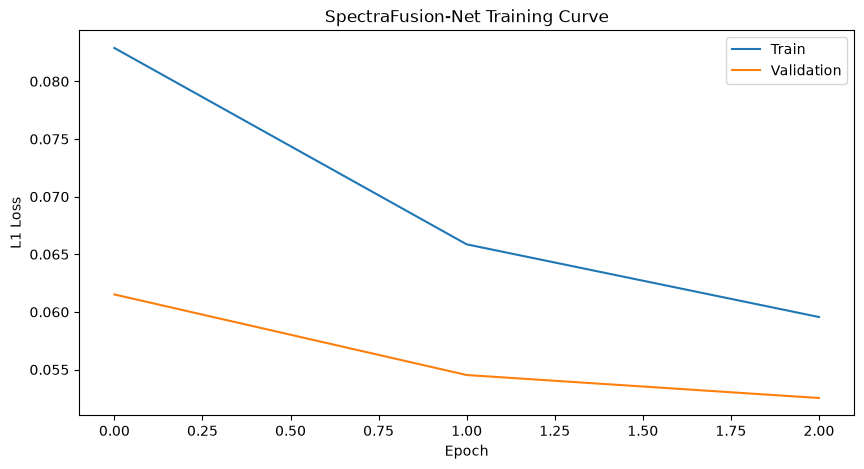

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("SpectraFusion-Net Training Curve")
plt.legend()
plt.show()